## Data Collection

In [35]:
import pandas as pd
import numpy as np
impor = "Students Social Media Addiction.csv"
data = pd.read_csv(impor)
data.head(5)

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [36]:
data.shape

(705, 13)

## Data Cleaning
Cek duplikat dan membuangnya, pemeriksaan typo dan outlier (inkonsistensi data), data formatting, dan data split

### Index

In [37]:
data.set_index('Student_ID', inplace=True)

### Duplikat
Mengecek apakah ada data duplikat. Hasilnya terdapat 1 data duplikat

In [38]:
duplikat = data.duplicated().sum()
duplikat

np.int64(1)

In [39]:
data_duplikat = data[data.duplicated(keep=False)]
display(data_duplikat)

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
Student_ID,,,,,,,,,,,,
242,21,Male,Graduate,Italy,5.4,Instagram,Yes,6.7,5,Single,3,7
274,21,Male,Graduate,Italy,5.4,Instagram,Yes,6.7,5,Single,3,7


In [40]:
data = data.drop_duplicates()

In [41]:
data.shape

(704, 12)

### Mengecek *missing value*

In [42]:
data.isnull().sum()

Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

### Data Formatting
Mengecek jenis data. Karena seluruh kolom sudah sesuai dengan tipe data, maka tidak ada kolom yang perlu diubah tipe datanya

In [43]:
data.dtypes

Age                               int64
Gender                              str
Academic_Level                      str
Country                             str
Avg_Daily_Usage_Hours           float64
Most_Used_Platform                  str
Affects_Academic_Performance        str
Sleep_Hours_Per_Night           float64
Mental_Health_Score               int64
Relationship_Status                 str
Conflicts_Over_Social_Media       int64
Addicted_Score                    int64
dtype: object

### Identifikasi Outlier
Cek outlier menggunakan metode Tukey's Fences

*   Batas bawah = Q1 - 1.5 * IQR
*   Batas atas = Q3 + 1.5 * IQR

Hasilnya ditemukan 3 outlier pada kolom Avg Daily Usage Hours.

In [44]:
# mengambil hanya kolom-kolom angka dari dataset `data`
numerik = data.select_dtypes(include=np.number).columns
jml_outlier = {}

for col in numerik:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    b_bawah = Q1 - 1.5 * IQR
    b_atas = Q3 + 1.5 * IQR

    # mencari data yang berada di bawah batas bawah atau berada di atas batas atas
    outlier = data[(data[col] < b_bawah) | (data[col] > b_atas)]
    pjg_outliers = len(outlier)
    jml_outlier[col] = pjg_outliers

    print(f"\nColumn: {col}")
    print(f"  Q1: {Q1:.2f}")
    print(f"  Q3: {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Lower Bound: {b_bawah:.2f}")
    print(f"  Upper Bound: {b_atas:.2f}")
    print(f"  Number of Outliers: {pjg_outliers}")
    print(f"  Outlier: {outlier}")
    print(f"  Pjg outliers: {pjg_outliers}")
    print(f"  Jml outlier: {jml_outlier}")



Column: Age
  Q1: 19.00
  Q3: 22.00
  IQR: 3.00
  Lower Bound: 14.50
  Upper Bound: 26.50
  Number of Outliers: 0
  Outlier: Empty DataFrame
Columns: [Age, Gender, Academic_Level, Country, Avg_Daily_Usage_Hours, Most_Used_Platform, Affects_Academic_Performance, Sleep_Hours_Per_Night, Mental_Health_Score, Relationship_Status, Conflicts_Over_Social_Media, Addicted_Score]
Index: []
  Pjg outliers: 0
  Jml outlier: {'Age': 0}

Column: Avg_Daily_Usage_Hours
  Q1: 4.10
  Q3: 5.80
  IQR: 1.70
  Lower Bound: 1.55
  Upper Bound: 8.35
  Number of Outliers: 3
  Outlier:             Age  Gender Academic_Level  Country  Avg_Daily_Usage_Hours  \
Student_ID                                                               
7            23    Male       Graduate  Germany                    1.5   
487          20  Female  Undergraduate      USA                    8.4   
497          19  Female  Undergraduate      USA                    8.5   

           Most_Used_Platform Affects_Academic_Performance  \


### Konsistensi Data
Untuk mengidentifikasi adanya *typo* dalam data, digunakan `value_counts()` untuk setiap kolom bertipe `object`. Hasilnya, tidak ada *typo* dalam data

In [45]:
cols = data.select_dtypes(include='object').columns

for col in cols:
    print(f"\n{col}")
    print(data[col].value_counts())


Gender
Gender
Female    353
Male      351
Name: count, dtype: int64

Academic_Level
Academic_Level
Undergraduate    353
Graduate         324
High School       27
Name: count, dtype: int64

Country
Country
India          53
USA            40
Canada         34
France         27
Spain          27
               ..
Iraq            1
Yemen           1
Syria           1
Afghanistan     1
Bhutan          1
Name: count, Length: 110, dtype: int64

Most_Used_Platform
Most_Used_Platform
Instagram    248
TikTok       154
Facebook     123
WhatsApp      54
Twitter       30
LinkedIn      21
WeChat        15
Snapchat      13
LINE          12
KakaoTalk     12
VKontakte     12
YouTube       10
Name: count, dtype: int64

Affects_Academic_Performance
Affects_Academic_Performance
Yes    452
No     252
Name: count, dtype: int64

Relationship_Status
Relationship_Status
Single             383
In Relationship    289
Complicated         32
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_20752\4273598616.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols = data.select_dtypes(include='object').columns


In [46]:
# menampilkan seluruh baris pada kolom Country dengan limit tak terbatas (None)
# with digunakan agar pengaturan hanya berlaku pada blok kode di bawahnya. Setelah eksekusi, pengaturan kembali ke kondisi default
with pd.option_context('display.max_rows', None):
    print(data['Country'].value_counts())

Country
India              53
USA                40
Canada             34
France             27
Spain              27
Mexico             27
Denmark            27
Switzerland        27
Ireland            27
Turkey             27
UK                 22
Japan              21
Russia             21
Bangladesh         20
Italy              20
Pakistan           19
Nepal              19
Sri Lanka          19
Maldives           19
China              16
Poland             16
Australia          14
Germany            14
South Korea        13
Brazil              8
Netherlands         8
New Zealand         8
Singapore           8
Malaysia            8
UAE                 8
Finland             8
Sweden              1
Norway              1
Belgium             1
Austria             1
Portugal            1
Greece              1
Thailand            1
Vietnam             1
Philippines         1
Indonesia           1
Taiwan              1
Hong Kong           1
Israel              1
Egypt               1
Mo

### Missing Value
Mengecek apakah ada *missing value* dalam data. Hasilnya tidak ada

In [47]:
x_test.isnull().sum()

Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
dtype: int64

## Data Understanding

### Statistik deskriptif

In [16]:
data.describe()

,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,704.000000,704.000000,704.000000,704.000000,704.000000,704.000000
mean,20.659091,4.918040,6.869176,6.228693,2.849432,6.436080
std,1.400153,1.258157,1.127631,1.104871,0.958632,1.588151
min,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


### Histogram
Visualisasi Histogram untuk fitur numerik VS Addicted Score

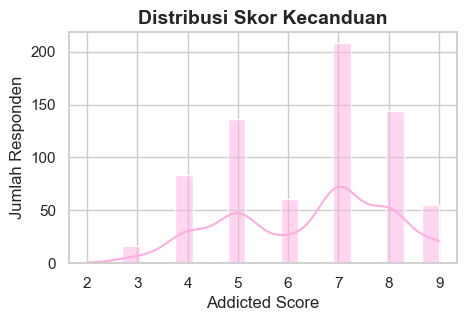

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tema grafik
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 3))

# Membuat Histogram. bins=20 berarti data dibagi jadi 20 interval. kde buat nambahin garis distribusi data
sns.histplot(data['Addicted_Score'], kde=True, color='#FFADE0', bins=20)
plt.title('Distribusi Skor Kecanduan', fontsize=14, fontweight='bold')
plt.xlabel('Addicted Score')
plt.ylabel('Jumlah Responden')
plt.show()

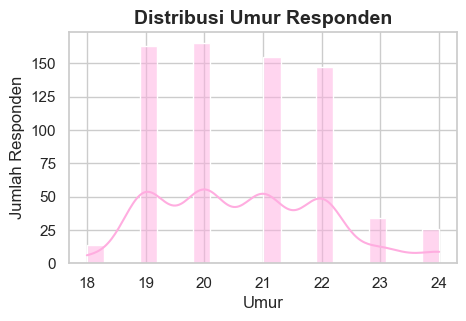

In [53]:
# Mengatur tema grafik
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 3))

# Membuat Histogram. bins=20 berarti data dibagi jadi 20 interval. kde buat nambahin garis distribusi data
sns.histplot(data['Age'], kde=True, color='#FFADE0', bins=20)
plt.title('Distribusi Umur Responden', fontsize=14, fontweight='bold')
plt.xlabel('Umur')
plt.ylabel('Jumlah Responden')
plt.show()

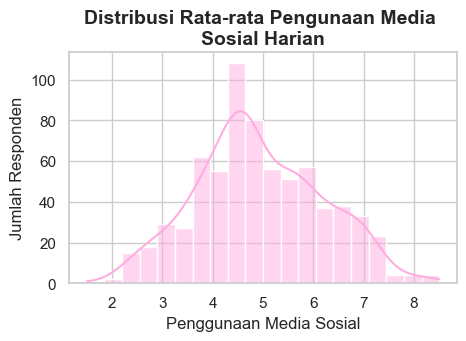

In [54]:
# Mengatur tema grafik
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 3))

# Membuat Histogram. bins=20 berarti data dibagi jadi 20 interval. kde buat nambahin garis distribusi data
sns.histplot(data['Avg_Daily_Usage_Hours'], kde=True, color='#FFADE0', bins=20)
plt.title('Distribusi Rata-rata Pengunaan Media \nSosial Harian', fontsize=14, fontweight='bold')
plt.xlabel('Penggunaan Media Sosial')
plt.ylabel('Jumlah Responden')
plt.show()

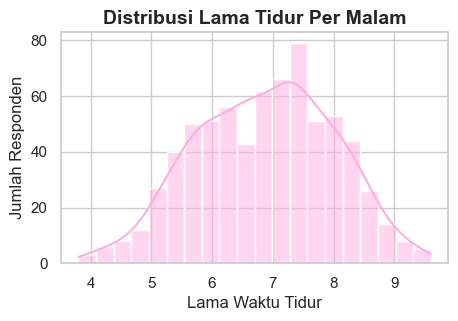

In [55]:
# Mengatur tema grafik
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 3))

# Membuat Histogram. bins=20 berarti data dibagi jadi 20 interval. kde buat nambahin garis distribusi data
sns.histplot(data['Sleep_Hours_Per_Night'], kde=True, color='#FFADE0', bins=20)
plt.title('Distribusi Lama Tidur Per Malam', fontsize=14, fontweight='bold')
plt.xlabel('Lama Waktu Tidur')
plt.ylabel('Jumlah Responden')
plt.show()

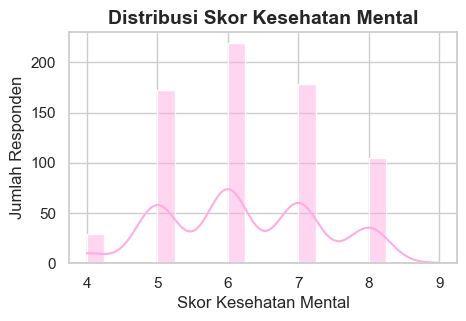

In [56]:
# Mengatur tema grafik
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 3))

# Membuat Histogram. bins=20 berarti data dibagi jadi 20 interval. kde buat nambahin garis distribusi data
sns.histplot(data['Mental_Health_Score'], kde=True, color='#FFADE0', bins=20)
plt.title('Distribusi Skor Kesehatan Mental', fontsize=14, fontweight='bold')
plt.xlabel('Skor Kesehatan Mental')
plt.ylabel('Jumlah Responden')
plt.show()

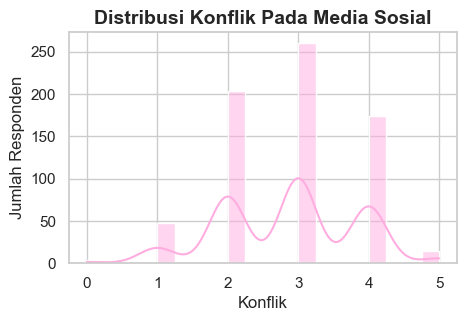

In [57]:
# Mengatur tema grafik
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 3))

# Membuat Histogram. bins=20 berarti data dibagi jadi 20 interval. kde buat nambahin garis distribusi data
sns.histplot(data['Conflicts_Over_Social_Media'], kde=True, color='#FFADE0', bins=20)
plt.title('Distribusi Konflik Pada Media Sosial', fontsize=14, fontweight='bold')
plt.xlabel('Konflik')
plt.ylabel('Jumlah Responden')
plt.show()

### Bar Chart
Visualisasi grafik batang untuk disribusi fitur kategorik

C:\Users\DELL\AppData\Local\Temp\ipykernel_20752\657965909.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data['Country'],


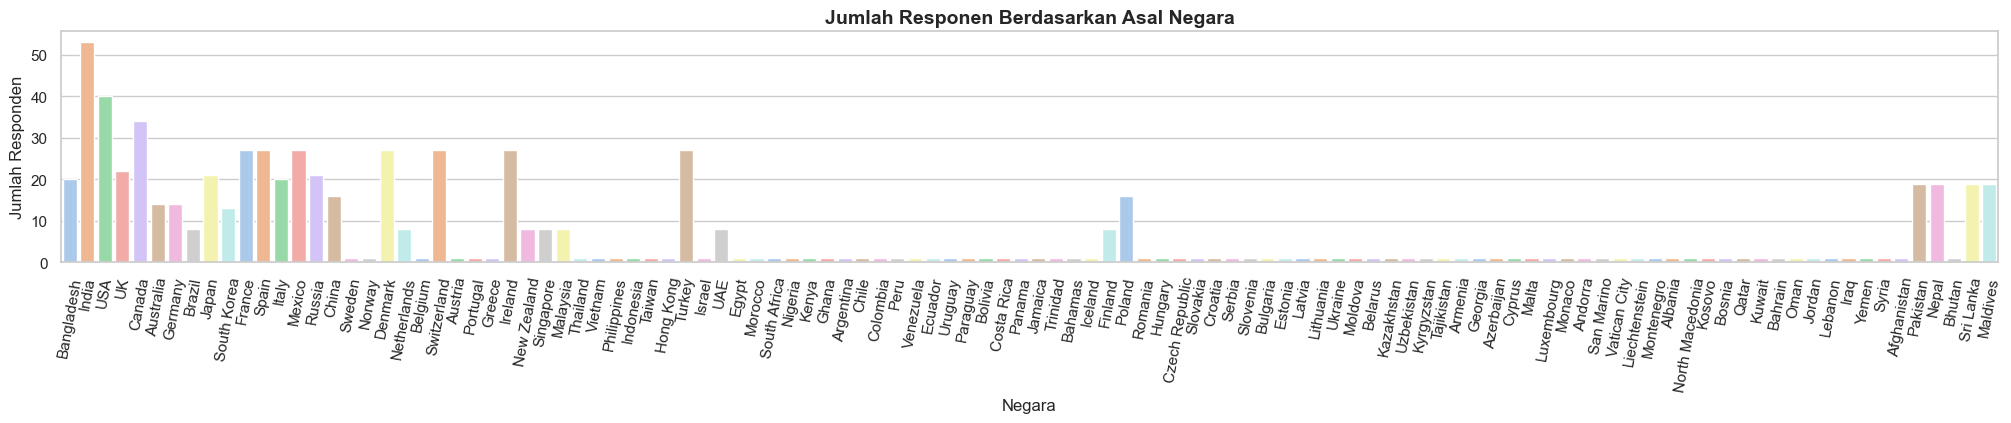

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(25, 3))

# Membuat Bar Chart
sns.countplot(x=data['Country'],
              palette='pastel')
plt.title('Jumlah Responen Berdasarkan Asal Negara', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Responden')
plt.xlabel('Negara')
plt.xticks(rotation=80)

plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_20752\4221758365.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=data['Most_Used_Platform'],


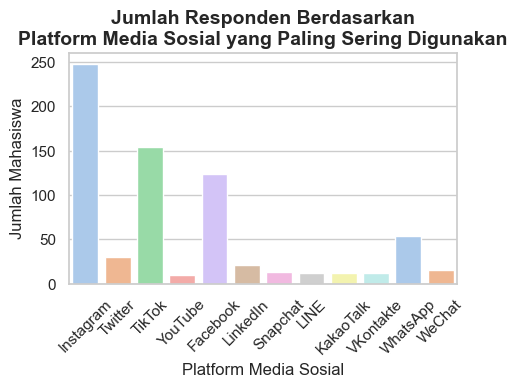

In [59]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 3))

# Membuat Bar Chart
sns.countplot(x=data['Most_Used_Platform'],
              palette='pastel')
plt.title('Jumlah Responden Berdasarkan\nPlatform Media Sosial yang Paling Sering Digunakan', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Mahasiswa')
plt.xlabel('Platform Media Sosial')
plt.xticks(rotation=45)

plt.show()

### Pie Chart
Visualisasi grafik pie untuk distribursi proporsi fitur kategorik

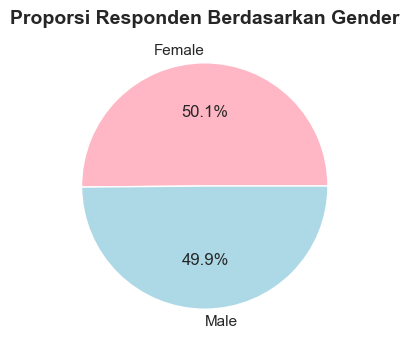

In [60]:
gender = data['Gender'].value_counts()

warna = ['#FFB7C5', '#ADD8E6', '#FFD1DC', '#E0B0FF']

# Membuat Pie Chart
plt.figure(figsize=(4, 4))
plt.pie(gender,
        labels=gender.index,
        autopct='%1.1f%%', # Menampilkan angka persentase
        #startangle=90,     # Memutar grafik agar lebih proporsional
        colors=warna)
plt.title('Proporsi Responden Berdasarkan Gender', fontsize=14, fontweight='bold')
plt.show()

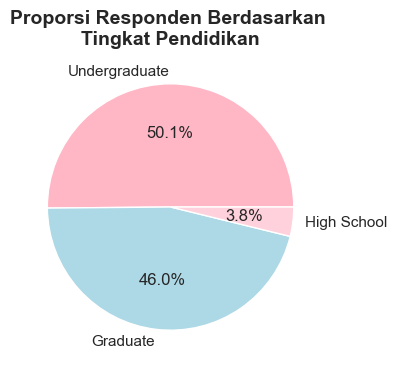

In [61]:
Academic_Level = data['Academic_Level'].value_counts()

# Membuat Pie Chart
plt.figure(figsize=(4, 4))
plt.pie(Academic_Level,
        labels=Academic_Level.index,
        autopct='%1.1f%%', # Menampilkan angka persentase
        colors=warna)
plt.title('Proporsi Responden Berdasarkan \nTingkat Pendidikan', fontsize=14, fontweight='bold')
plt.show()

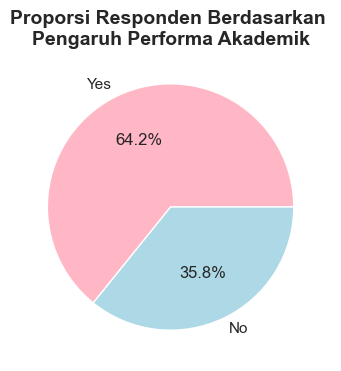

In [62]:
Affects_Academic_Performance = data['Affects_Academic_Performance'].value_counts()

# Membuat Pie Chart
plt.figure(figsize=(4, 4))
plt.pie(Affects_Academic_Performance,
        labels=Affects_Academic_Performance.index,
        autopct='%1.1f%%', # Menampilkan angka persentase
        colors=warna)
plt.title('Proporsi Responden Berdasarkan \nPengaruh Performa Akademik', fontsize=14, fontweight='bold')
plt.show()

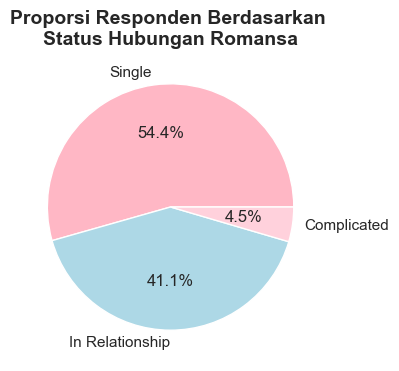

In [63]:
Relationship_Status = data['Relationship_Status'].value_counts()

# Membuat Pie Chart
plt.figure(figsize=(4, 4))
plt.pie(Relationship_Status,
        labels=Relationship_Status.index,
        autopct='%1.1f%%', # Menampilkan angka persentase
        colors=warna)
plt.title('Proporsi Responden Berdasarkan \nStatus Hubungan Romansa', fontsize=14, fontweight='bold')
plt.show()

### Heatmap
Grafik heatmap untuk hasil dari analisis korelasi

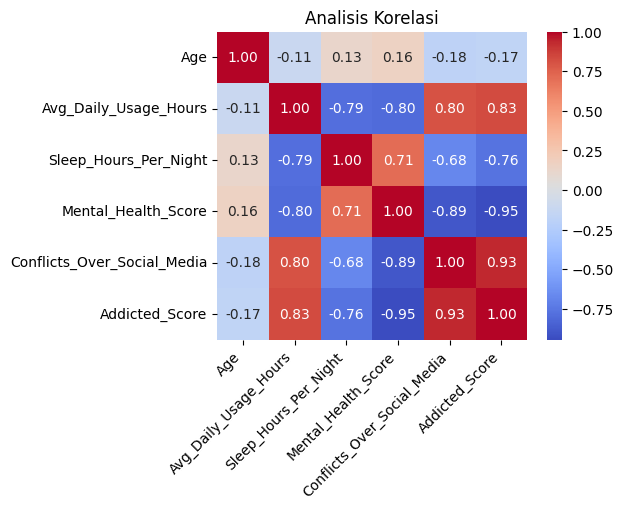

Variabel numerik yang paling berpengaruh ke skor kecanduan:

 Addicted_Score                 1.000000
Conflicts_Over_Social_Media    0.933607
Avg_Daily_Usage_Hours          0.831968
Age                           -0.166540
Sleep_Hours_Per_Night         -0.764863
Mental_Health_Score           -0.945404
Name: Addicted_Score, dtype: float64


In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

numerik = data.select_dtypes(include=['number'])
korelasi = numerik.corr(method='pearson')

plt.figure(figsize=(5, 4))
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Analisis Korelasi")
plt.xticks(rotation=45, ha='right')
plt.show()

print("Variabel numerik yang paling berpengaruh ke skor kecanduan:")
print("\n", korelasi['Addicted_Score'].sort_values(ascending=False))

### Kategorik VS Addicted Score
Distribusi fitur kategorik terhadap Addicted Score

In [50]:
data.head(3)

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
Student_ID,,,,,,,,,,,,
1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9


In [64]:
for col in ['Country', 'Academic_Level', 'Most_Used_Platform', 'Relationship_Status', 'Affects_Academic_Performance']:
    print(f"\n=== {col} ===")
    print(data.groupby(col)['Addicted_Score'].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False))


=== Country ===
                    mean  median       std  count
Country                                          
Armenia         9.000000     9.0       NaN      1
Ecuador         9.000000     9.0       NaN      1
Czech Republic  9.000000     9.0       NaN      1
Liechtenstein   9.000000     9.0       NaN      1
Lebanon         9.000000     9.0       NaN      1
...                  ...     ...       ...    ...
San Marino      4.000000     4.0       NaN      1
Germany         3.857143     4.0  0.534522     14
Japan           3.476190     3.0  0.601585     21
Sweden          3.000000     3.0       NaN      1
Slovakia        3.000000     3.0       NaN      1

[110 rows x 4 columns]

=== Academic_Level ===
                    mean  median       std  count
Academic_Level                                   
High School     8.037037     8.0  1.125969     27
Undergraduate   6.492918     7.0  1.634354    353
Graduate        6.240741     7.0  1.490135    324

=== Most_Used_Platform ===
       